# Few Shot Spam Classification

The Merriam Webster dictionary defines spam as *unsolicited usually commercial messages (such as emails, text messages, or internet postings) sent to a large number of recipients or posted in a large number of places*. Any social platform that allows its users to share and receive messages requires a mechanism to prevent bad actors from flooding it with malicious content, lest it suffers reputational, or at worst even legal and financial damage.

Evolving, adversarial approaches of spammers, high spam volume, lack of labelled data, and class imbalance$-$spam is far less frequent than ham$-$can make identifying and removing spam challenging. 

In this project I will apply **few-shot learning**, a deep learning technique where a pretrained model is adapted to a new task using a small number of labelled samples, for spam classification, with the goal of striking a balance between minimizing exposure to malicious content (i.e., false negatives), and blocking legitimate messages (i.e., false positives). 

# Dataset

For this toy project I will use the UCI Youtube Spam Collection dataset, a public dataset 951 ham and 1005 spam messages. To increase the challenge and simulate a real world scenario, I will only use 100 samples for training and validation, and I will only fine-tune the model on the message content. 

In [48]:
from ucimlrepo import fetch_ucirepo
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, f1_score, confusion_matrix, recall_score
from transformers import AutoModelForSequenceClassification, AutoTokenizer
from transformers import Trainer, TrainingArguments
import torch
import time
import matplotlib.pyplot as plt

In [31]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
# fetch dataset 
youtube_spam_collection = fetch_ucirepo(id=380) 

# data (as pandas dataframes) 
X = youtube_spam_collection.data.features 
y = youtube_spam_collection.data.targets

y.groupby("CLASS").size()

CLASS
0     951
1    1005
dtype: int64

In [3]:
# split data into training, validation and testing sets
X_train, X_test, y_train, y_test = train_test_split(X[["CONTENT"]], y, train_size=100)
X_train, X_valid, y_train, y_valid = train_test_split(X_train, y_train, train_size=70)

# Pretrained Model Selection

For the spam classification task, I will use **pretrained transformer models** with a general language understanding, including BERT, DistilBERT, a fast, lightweight version of BERT, and RoBERTa, a retrained version of BERT. 

Bidirectional Encoder Representations from Transformers (BERT) is transformer model that uses the self-attention mechanism to generate high quality encodings which can be used for a variety of downstream tasks, including sentence classification, question answering and sentence tagging. 

In [5]:
def get_model_and_tokenizer(checkpoint):
    model = AutoModelForSequenceClassification.from_pretrained(checkpoint)
    tokenizer = AutoTokenizer.from_pretrained(checkpoint)
    return model, tokenizer

# Data Preprocessing

In [40]:
class SpamDataset(torch.utils.data.Dataset):
    def __init__(self, content_list, label_list, tokenizer):
        super().__init__()
        self.content_list = content_list
        self.label_list = label_list
        self.encodings = tokenizer(
            self.content_list, return_tensors="pt", 
            padding=True, truncation=True)

    def __getitem__(self, idx):
        item = {key: torch.tensor(value[idx]) for key, value in self.encodings.items()}
        item["label"] = torch.tensor(self.label_list[idx])
        return item

    def __len__(self):
        return len(self.label_list)

In [41]:
def load_data(tokenizer):
    train_ds = SpamDataset(
        X_train["CONTENT"].tolist(), y_train["CLASS"].tolist(),
        tokenizer)
    valid_ds = SpamDataset(
        X_valid["CONTENT"].tolist(), y_valid["CLASS"].tolist(),
        tokenizer)
    test_ds = SpamDataset(
        X_test["CONTENT"].tolist(), y_test["CLASS"].tolist(),
        tokenizer)

    return train_ds, valid_ds, test_ds

# Train And Evaluate Models

In [34]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = logits.argmax(axis=-1)
    
    accuracy = accuracy_score(labels, predictions)
    precision = precision_score(labels, predictions)
    f1 = f1_score(labels, predictions)
    recall = recall_score(p.label_ids, preds)
    
    return {"accuracy": accuracy, "precision": precision, "f1_score": f1, "recall": recall}

In [36]:
# start with DistilBERT model
distilbert_model, distilbert_tokenizer = get_model_and_tokenizer("distilbert-base-uncased")
train_ds, valid_ds, test_ds = load_data(distilbert_tokenizer)
distilbert_optimizer = torch.optim.Adam(distilbert_model.parameters(), lr=5e-5)

distilbert_training_args = TrainingArguments(
    output_dir="./distilbert",
    num_train_epochs=10,
    per_device_train_batch_size=10,
    per_device_eval_batch_size=10,
    logging_dir="./logs",
    logging_steps=10
)

distilbert_trainer = Trainer(
    model=distilbert_model,
    args=distilbert_training_args,
    train_dataset=train_ds,
    eval_dataset=valid_ds,
    compute_metrics=compute_metrics,
    optimizers=(distilbert_optimizer, None)
)

start_time = time.time()
distilbert_trainer.train()
print(f"Total training time: {(time.time()-start_time)/60:0.2f} min")

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Step,Training Loss
10,0.621100
20,0.353700
30,0.201400
40,0.089300
50,0.026900
60,0.012300
70,0.009600


Total training time: 0.34 min


In [37]:
distilbert_trainer.evaluate()

{'eval_loss': 0.09429468959569931,
 'eval_accuracy': 0.9666666666666667,
 'eval_precision': 0.9230769230769231,
 'eval_f1_score': 0.96,
 'eval_runtime': 0.0585,
 'eval_samples_per_second': 512.728,
 'eval_steps_per_second': 51.273,
 'epoch': 10.0}

DistilBERT performed surprisingly well on the validation set. The model's predictions were highly accurate, and the model minimized both false positives and false negatives. The small gap between the f1 and precision score indicates that the model generated more false positives than false negatives$-$which is acceptable for the current use case. 

In [54]:
# move on to BERT model
bert_model, bert_tokenizer = get_model_and_tokenizer("bert-base-uncased")
train_ds, valid_ds, test_ds = load_data(bert_tokenizer)
bert_optimizer = torch.optim.Adam(bert_model.parameters(), lr=5e-5)

bert_training_args = TrainingArguments(
    output_dir="./bert",
    num_train_epochs=10,
    per_device_train_batch_size=10,
    per_device_eval_batch_size=10,
    logging_dir="./logs",
    logging_steps=10
)

bert_trainer = Trainer(
    model=bert_model,
    args=bert_training_args,
    train_dataset=train_ds,
    eval_dataset=valid_ds,
    compute_metrics=compute_metrics,
    optimizers=(bert_optimizer, None)
)

start_time = time.time()
bert_trainer.train()
print(f"Total training time: {(time.time()-start_time)/60:0.2f} min")

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Step,Training Loss
10,0.564800
20,0.227300
30,0.063600
40,0.009100
50,0.002800
60,0.001500
70,0.001100
80,0.000900
90,0.000800
100,0.000700


Total training time: 1.33 min


In [60]:
bert_trainer.evaluate()

{'eval_loss': 0.009107938967645168,
 'eval_accuracy': 1.0,
 'eval_precision': 1.0,
 'eval_f1_score': 1.0,
 'eval_runtime': 0.3678,
 'eval_samples_per_second': 81.569,
 'eval_steps_per_second': 8.157,
 'epoch': 20.0}

It looks like BERT is doing a perfect job classifying the validation data, which is surprising. The precision, accuracy and f1 scores are all 1.0! Let's see how it performs on the testing dataset.

# Evaluation

In [61]:
def plot_confusion_matrix(cm,
                          target_names,
                          title='Confusion matrix',
                          cmap=None,
                          normalize=True):
    """
    given a sklearn confusion matrix (cm), make a nice plot

    Arguments
    ---------
    cm:           confusion matrix from sklearn.metrics.confusion_matrix

    target_names: given classification classes such as [0, 1, 2]
                  the class names, for example: ['high', 'medium', 'low']

    title:        the text to display at the top of the matrix

    cmap:         the gradient of the values displayed from matplotlib.pyplot.cm
                  see http://matplotlib.org/examples/color/colormaps_reference.html
                  plt.get_cmap('jet') or plt.cm.Blues

    normalize:    If False, plot the raw numbers
                  If True, plot the proportions

    Usage
    -----
    plot_confusion_matrix(cm           = cm,                  # confusion matrix created by
                                                              # sklearn.metrics.confusion_matrix
                          normalize    = True,                # show proportions
                          target_names = y_labels_vals,       # list of names of the classes
                          title        = best_estimator_name) # title of graph

    Citiation
    ---------
    http://scikit-learn.org/stable/auto_examples/model_selection/plot_confusion_matrix.html

    """
    import matplotlib.pyplot as plt
    import numpy as np
    import itertools

    accuracy = np.trace(cm) / float(np.sum(cm))
    misclass = 1 - accuracy

    if cmap is None:
        cmap = plt.get_cmap('Blues')

    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    
    plt.figure(figsize=(5, 4))
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()

    if target_names is not None:
        tick_marks = np.arange(len(target_names))
        plt.xticks(tick_marks, target_names, rotation=45)
        plt.yticks(tick_marks, target_names)

    thresh = cm.max() / 1.5 if normalize else cm.max() / 2
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        if normalize:
            plt.text(j, i, "{:0.3f}".format(cm[i, j]),
                     horizontalalignment="center",
                     color="white" if cm[i, j] > thresh else "black")
        else:
            plt.text(j, i, "{:,}".format(cm[i, j]),
                     horizontalalignment="center",
                     color="white" if cm[i, j] > thresh else "black")


    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label\naccuracy={:0.3f}; misclass={:0.3f}'.format(accuracy, misclass))
    plt.show()

In [62]:
predictions = bert_trainer.predict(test_ds)
predictions.metrics

{'test_loss': 0.38183730840682983,
 'test_accuracy': 0.9310344827586207,
 'test_precision': 0.9562363238512035,
 'test_f1_score': 0.9317697228144989,
 'test_runtime': 31.188,
 'test_samples_per_second': 59.51,
 'test_steps_per_second': 5.964}

In [63]:
y_true = predictions.label_ids
y_pred = predictions.predictions.argmax(axis=-1)
cm = confusion_matrix(y_true, y_pred)

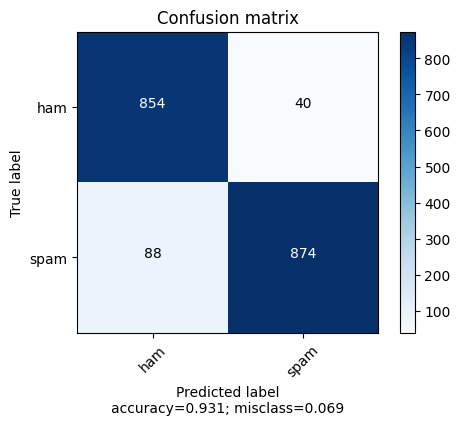

In [69]:
plot_confusion_matrix(cm, ["ham", "spam"], normalize=False)

Based on these results, it appears that the model performed well, but not perfectly on the testing data: 93% of the model's predictions were accurate; when the model predicted spam, it was correct 95.6% of the time; and the model balanced precision and recall relatively well, with an f1 score of 93.2%. 

As can be seen in the confusion matix, the model recalled most but not all of the spam samples, with a recall of 90.8%. For my toy use case, I wish to minimize the false negative rate, because I do not want to minimize exposure to spam. In practice, to reduce the number of type 2 errors, I would reactively make changes after deployment, such as adjusting the classification threshold, based on the live performance of the model. 